In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras_tuner as kt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


# ---------------- GPU SETUP ----------------


In [4]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], 'GPU')
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("✅ GPU Enabled:", gpus)
    except RuntimeError as e:
        print(e)
else:
    print("❌ GPU not found, using CPU")

✅ GPU Enabled: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
df = pd.read_csv("../../Data/cleaned.csv")

X = df.drop("Exited", axis=1)
y = to_categorical(df["Exited"])



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
categorical = ['Gender', 'Geography']

numerical = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard',
    'IsActiveMember', 'EstimatedSalary'
]

In [6]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [7]:

# ---------------- NEURON OPTIONS (2^n) ----------------
NEURON_OPTIONS = [2, 4, 8, 16, 32, 64, 128, 256]

# ---------------- MODEL BUILDER ----------------
def build_model(hp):
    model = Sequential()

    for i in range(hp.Int("num_layers", 1, 5)):

        units = hp.Choice(f'units_{i}', NEURON_OPTIONS)

        model.add(Dense(
            units=units,
            activation='relu'
        ))

        model.add(BatchNormalization())

        model.add(Dropout(
            rate=hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)
        ))

    # Output layer
    model.add(Dense(2, activation='sigmoid', dtype='float32'))

    optimizer = hp.Choice('optimizer', ['adam', 'rmsprop', 'sgd'])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# ---------------- TUNER (MAX 5 TRIALS ONLY) ----------------
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,   
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='churn_gpu_final'
)

# ---------------- GPU TRAINING ----------------
with tf.device('/GPU:0'):

    tuner.search(
        X_train, y_train,
        epochs=20,
        validation_split=0.2,
        batch_size=64,
        callbacks=[early_stop]
    )

# ---------------- BEST MODEL ----------------

best_hp = tuner.get_best_hyperparameters(1)[0]
best_model = build_model(best_hp)


print("\n🔥 BEST HYPERPARAMETERS")
print("Optimizer:", best_hp.get('optimizer'))
print("Layers:", best_hp.get('num_layers'))

for i in range(best_hp.get('num_layers')):
    print(f"Layer {i+1} Units:", best_hp.get(f'units_{i}'))
    print(f"Layer {i+1} Dropout:", best_hp.get(f'dropout_{i}'))

# ---------------- FINAL TRAINING ----------------
with tf.device('/GPU:0'):

    history = best_model.fit(
        X_train, y_train,
        epochs=100,
        validation_data=(X_test, y_test),
        batch_size=64,
        callbacks=[early_stop]
    )

# ---------------- EVALUATION ----------------
loss, accuracy = best_model.evaluate(X_test, y_test)

print("\n✅ FINAL TEST ACCURACY:", accuracy)

Reloading Tuner from tuner_dir\churn_gpu_final\tuner0.json

🔥 BEST HYPERPARAMETERS
Optimizer: adam
Layers: 2
Layer 1 Units: 32
Layer 1 Dropout: 0.0
Layer 2 Units: 2
Layer 2 Dropout: 0.1
Epoch 1/100
125/125 [==============================] - 1s 5ms/step - loss: 0.7378 - accuracy: 0.6010 - val_loss: 0.5850 - val_accuracy: 0.7330
Epoch 2/100
125/125 [==============================] - 0s 3ms/step - loss: 0.5797 - accuracy: 0.7287 - val_loss: 0.5064 - val_accuracy: 0.7910
Epoch 3/100
125/125 [==============================] - 0s 3ms/step - loss: 0.5091 - accuracy: 0.7812 - val_loss: 0.4523 - val_accuracy: 0.8215
Epoch 4/100
125/125 [==============================] - 0s 3ms/step - loss: 0.4617 - accuracy: 0.8104 - val_loss: 0.4071 - val_accuracy: 0.8445
Epoch 5/100
125/125 [==============================] - 0s 3ms/step - loss: 0.4177 - accuracy: 0.8341 - val_loss: 0.3772 - val_accuracy: 0.8550
Epoch 6/100
125/125 [==============================] - 0s 3ms/step - loss: 0.3954 - accuracy: 0.844

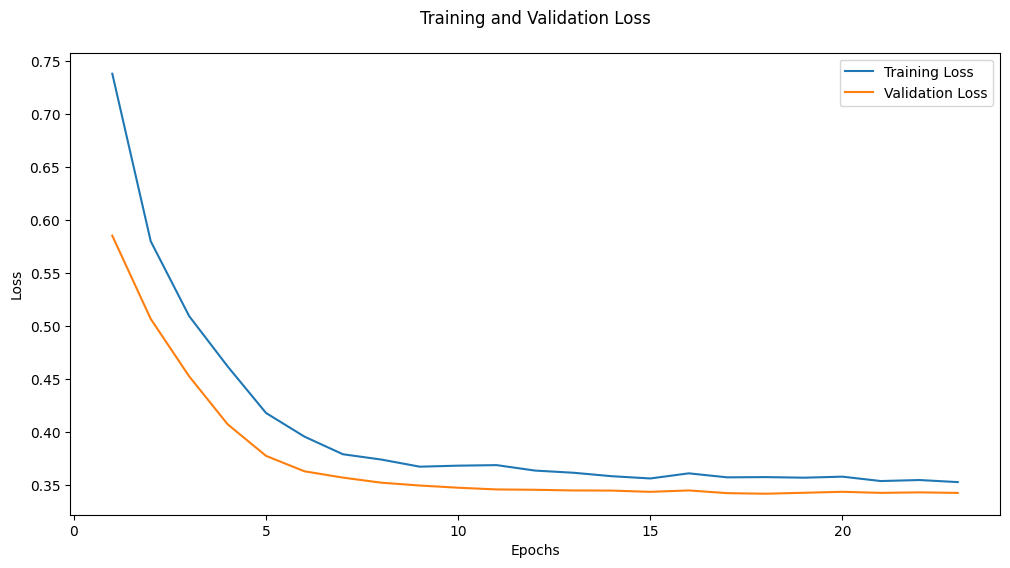

In [8]:
plt.figure(figsize=(12, 6))

train_loss = history.history['loss']
val_loss = history.history['val_loss']

epoch = range(1, len(train_loss) + 1)  

sns.lineplot(x=epoch, y=train_loss, label = 'Training Loss')
sns.lineplot(x=epoch, y=val_loss, label = 'Validation Loss')
plt.title('Training and Validation Loss\n')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



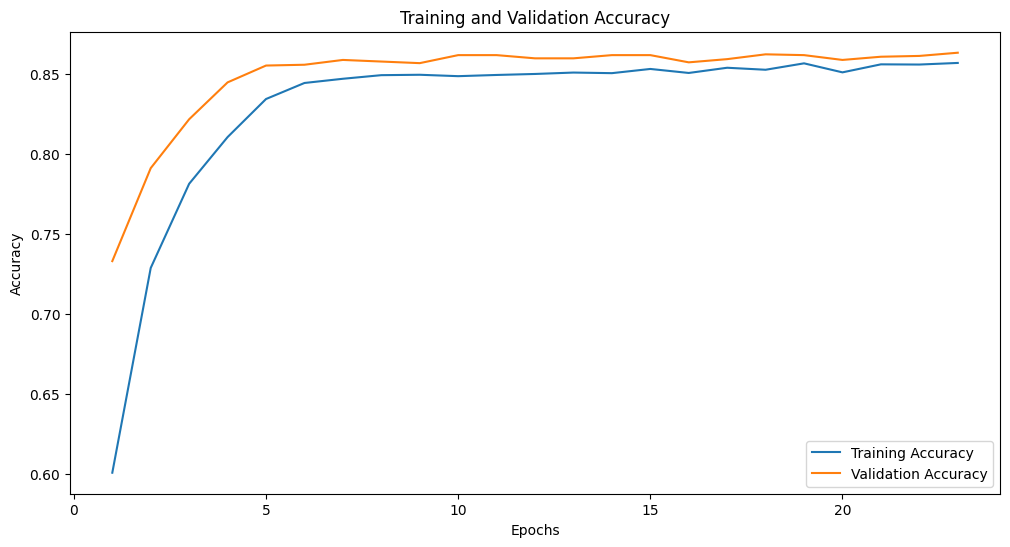

In [9]:
plt.figure(figsize=(12, 6))

epochs = range(1, len(train_loss) + 1) 

sns.lineplot(x=epochs, y=history.history['accuracy'], label='Training Accuracy')
sns.lineplot(x=epochs, y=history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [10]:
acc = best_model.evaluate(X_test, y_test)[1]

print(f'Accuracy of model is {acc}')


63/63 [==============================] - 0s 2ms/step - loss: 0.3415 - accuracy: 0.8620
Accuracy of model is 0.8619999885559082


63/63 [==============================] - 0s 2ms/step


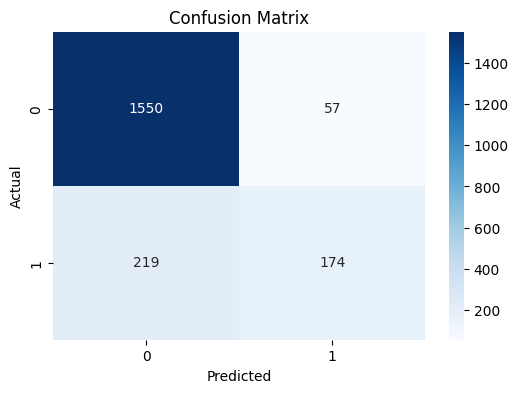


📊 Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.44      0.56       393

    accuracy                           0.86      2000
   macro avg       0.81      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000



In [11]:
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred_classes))

In [12]:
import os

# create folder
os.makedirs("Model", exist_ok=True)

# save final trained model
best_model.save("Model/churn_model.keras")

print("✅ Model saved successfully in Model folder")

✅ Model saved successfully in Model folder
